In [8]:
import os
cwd = os.getcwd()
words = open(cwd + '/../' + 'names.txt', 'r').read().splitlines()

In [9]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

**Exercise 01:**
Addestrare un modello linguistico a trigrammi, ovvero prendere due caratteri in input per predire il terzo. È possibile utilizzare sia il conteggio che una rete neurale. Valutare la loss function: ha migliorato le prestazioni rispetto a un modello a bigrammi?


In [15]:
import torch

/Users/dave/miniconda3/envs/4prep/lib/python3.12/site-packages/torch/_subclasses/functional_tensor.py:368: UserWarning: Failed to initialize NumPy: No module named 'numpy' (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:84.)
  cpu = _conversion_method_template(device=torch.device("cpu"))


In [16]:
N = torch.zeros((27,27), dtype=torch.int32)

In [21]:
chars = sorted(list(set(''.join(words))))
# mapping chars to index
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
# mapping index to char
itos = {i:s for s,i in stoi.items()}

In [23]:
# bigram model
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    idx1 = stoi[ch1]
    idx2 = stoi[ch2]
    N[idx1, idx2] += 1

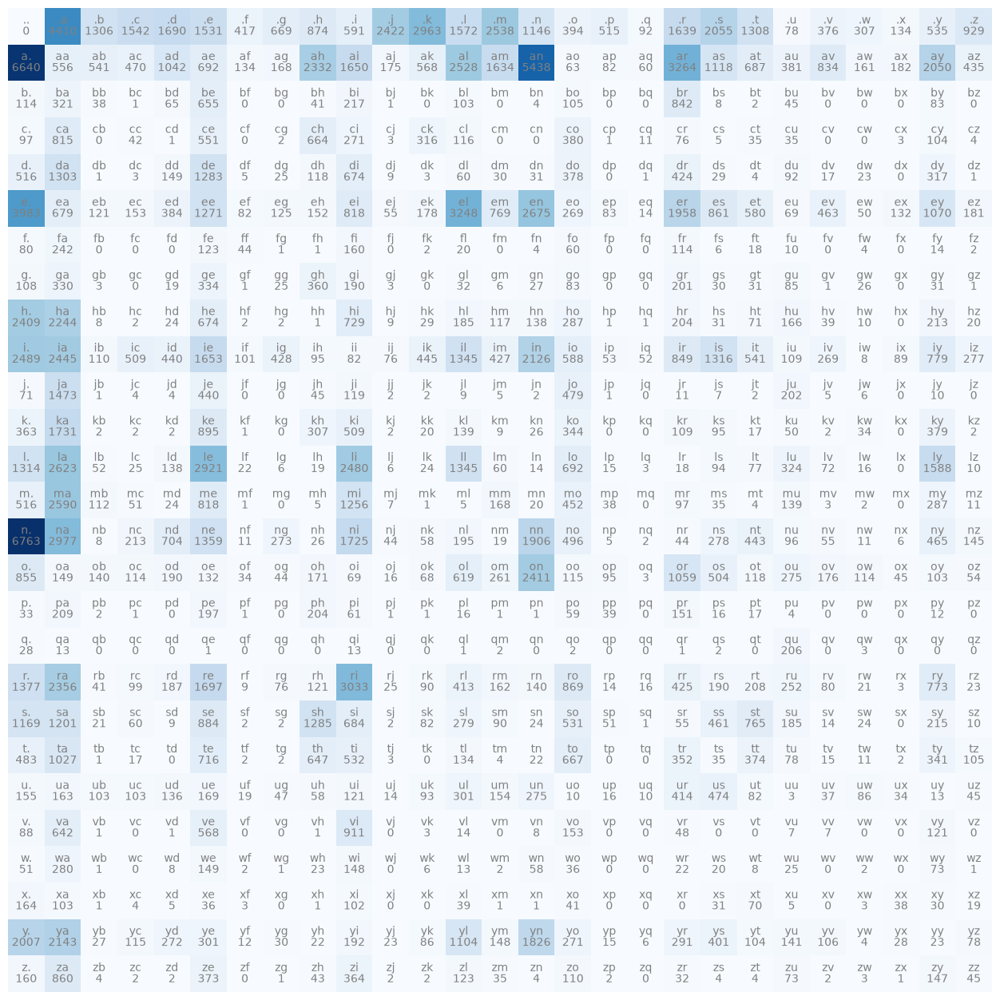

In [30]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N.tolist(), cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

Nel modello a trigrammi ho 2 caratteri in input e devo predire il terzo. Quindi devo estendere la griglia.

In [125]:
N_tr = torch.zeros((27*27,27), dtype=torch.int32)

In [126]:
bigrams = []
for i in range(27):
    for j in range(0, 27):
        bigrams.append(itos[i] + itos[j])

In [127]:
bigrams[:10]

['..', '.a', '.b', '.c', '.d', '.e', '.f', '.g', '.h', '.i']

In [128]:
chars = sorted(list(set(''.join(words))))
bigrams = sorted(bigrams)
# mapping bigram to index
btoi = {b:i for i, b in enumerate(bigrams)}
# mapping index to bigram
itob = {i:b for b,i in btoi.items()}

In [129]:
# trigram model
for w in words:
    chs = ['.'] * 2 + list(w) + ['.']
    for i in range(len(chs[:-2])):
        idx1 = btoi[chs[i] + chs[i+1]]
        idx2 = stoi[chs[i+2]]
        #print(chs[i] + chs[i+1], chs[i+2])
        #print(idx1, idx2)
        N_tr[idx1, idx2] += 1



In [130]:
plt.figure(figsize=(16,16))
plt.imshow(N.tolist(), cmap='Blues')
for i in range(27*26):
    for j in range(27):
        chstr = itob[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N_tr[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [168]:
P = N_tr.float()
P = P / P.sum(1, keepdim=True)

In [169]:
P.sum(1, keepdim=True).shape

torch.Size([729, 1])

In [170]:
# 729, 729 (P.shape)
# 729, 1   (P.sum.shape) -> column vector

In [171]:
rng = torch.Generator().manual_seed(2147483647)

for i in range(10):
    out = []
    b_ix = 0
    while True:
        p = P[b_ix]
        s_ix = torch.multinomial(p, num_samples=1, replacement=True, generator=rng).item()
        out.append(itos[s_ix])
        if s_ix==0:
            break
        bg = itob[b_ix][1] + itos[s_ix]
        b_ix = btoi[bg]
    print(''.join(out))

ce.
bra.
jalius.
rochityharlonimittain.
luwak.
ka.
da.
samiyah.
javer.
gotai.


In [172]:
# GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the negative log likelihood

# REMEMBER: the likelihood is the product of the single probs, so the log_lihelihood is the summation over the logprobs

# log(a*b*c) = log(a) + log(b) + log(c)

In [173]:
log_likelihood = 0.0
n = 0

for w in words:
    chs = ['.'] * 2 + list(w) + ['.']
    for i in range(len(chs[:-2])):
        idx1 = btoi[chs[i] + chs[i+1]]
        idx2 = stoi[chs[i+2]]
        prob = P[idx1, idx2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n=}')

log_likelihood=tensor(-498647.7812)
nll=tensor(498647.7812)
nll/n=tensor(2.1857)


In [188]:
# create mapping from xs to xs0 and xs1
ibtoiss = {}
for ib, b in itob.items():
    is0 = stoi[b[0]]
    is1 = stoi[b[1]]
    ibtoiss[ib] = [is0, is1]

In [189]:
ibtoiss

{0: [0, 0],
 1: [0, 1],
 2: [0, 2],
 3: [0, 3],
 4: [0, 4],
 5: [0, 5],
 6: [0, 6],
 7: [0, 7],
 8: [0, 8],
 9: [0, 9],
 10: [0, 10],
 11: [0, 11],
 12: [0, 12],
 13: [0, 13],
 14: [0, 14],
 15: [0, 15],
 16: [0, 16],
 17: [0, 17],
 18: [0, 18],
 19: [0, 19],
 20: [0, 20],
 21: [0, 21],
 22: [0, 22],
 23: [0, 23],
 24: [0, 24],
 25: [0, 25],
 26: [0, 26],
 27: [1, 0],
 28: [1, 1],
 29: [1, 2],
 30: [1, 3],
 31: [1, 4],
 32: [1, 5],
 33: [1, 6],
 34: [1, 7],
 35: [1, 8],
 36: [1, 9],
 37: [1, 10],
 38: [1, 11],
 39: [1, 12],
 40: [1, 13],
 41: [1, 14],
 42: [1, 15],
 43: [1, 16],
 44: [1, 17],
 45: [1, 18],
 46: [1, 19],
 47: [1, 20],
 48: [1, 21],
 49: [1, 22],
 50: [1, 23],
 51: [1, 24],
 52: [1, 25],
 53: [1, 26],
 54: [2, 0],
 55: [2, 1],
 56: [2, 2],
 57: [2, 3],
 58: [2, 4],
 59: [2, 5],
 60: [2, 6],
 61: [2, 7],
 62: [2, 8],
 63: [2, 9],
 64: [2, 10],
 65: [2, 11],
 66: [2, 12],
 67: [2, 13],
 68: [2, 14],
 69: [2, 15],
 70: [2, 16],
 71: [2, 17],
 72: [2, 18],
 73: [2, 19],
 74:

In [192]:
itob[340], ibtoiss[340], itos[12], itos[16]

('lp', [12, 16], 'l', 'p')

In [262]:
# create the training set of trigrams (x,y)
xs, ys = [], []

for w in words:
    chs = ['.'] * 2 + list(w) + ['.']
    for i in range(len(chs[:-2])):
        idx1 = btoi[chs[i] + chs[i+1]]
        idx2 = stoi[chs[i+2]]
        xs.append(idx1)
        ys.append(idx2)
    
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()

In [263]:
import torch.nn.functional as F
xenc0 = F.one_hot(torch.tensor([ibtoiss[x.item()] for x in xs])[:,0], num_classes=27)
xenc1 = F.one_hot(torch.tensor([ibtoiss[x.item()] for x in xs])[:,1], num_classes=27)
xenc = torch.cat((xenc0, xenc1), dim=1).float()
xenc.shape

torch.Size([228146, 54])

In [264]:
rng = torch.Generator().manual_seed(2147483647)
W = torch.randn((54,27), generator=rng, requires_grad=True)

In [ ]:
for k in range(500):
    # forward pass
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
    
    W.grad = None
    loss.backward()

    W.data += -1 * W.grad
print(loss.item())